   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

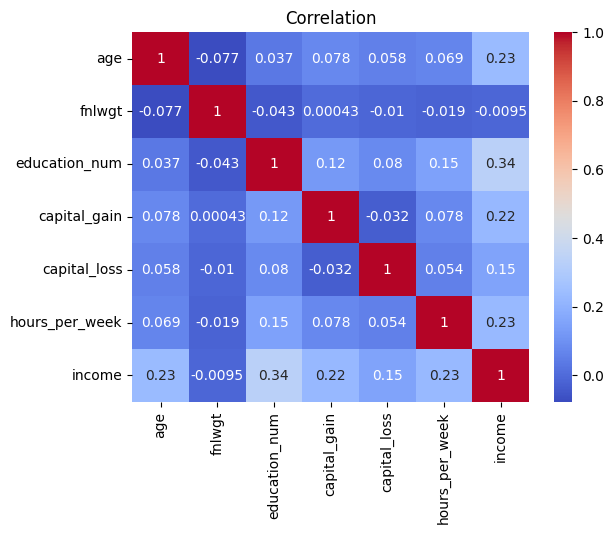

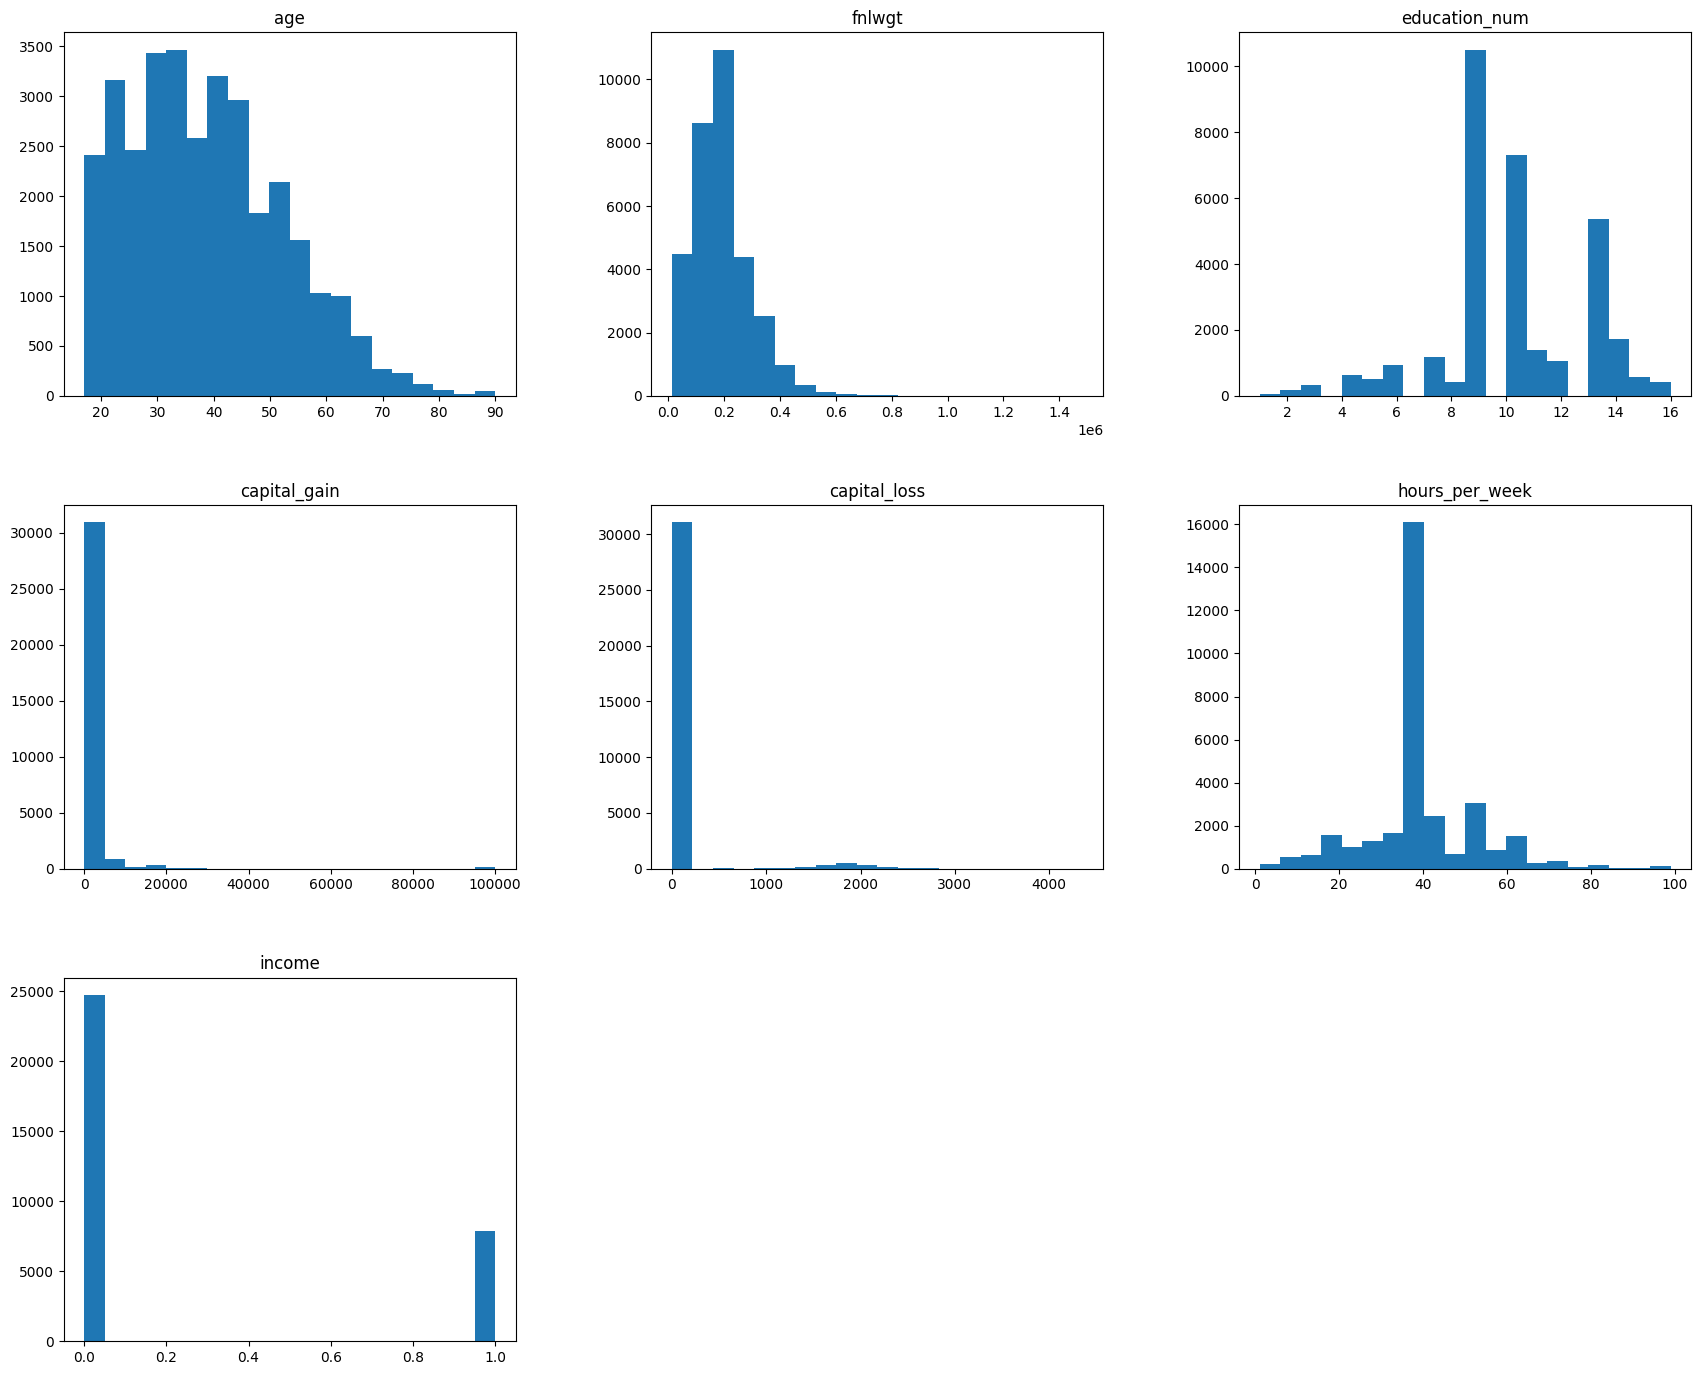

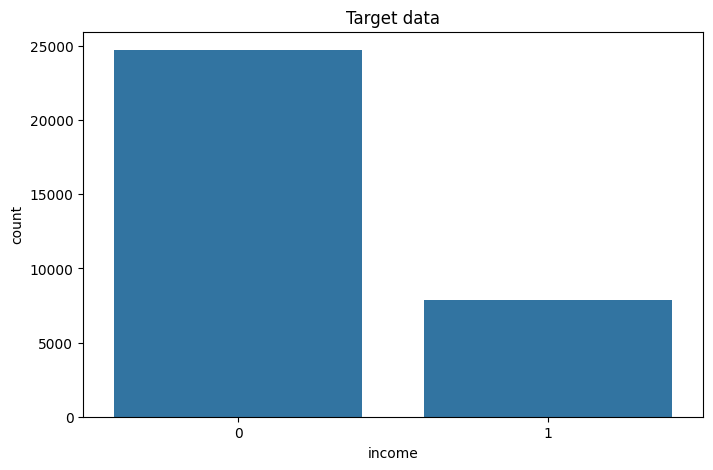

income
0    24720
1     7841
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

# Load dataset
#df = pd.read_csv('adult.csv')
#print(df.head())

# Repair the missing header
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 
    'marital_status', 'occupation', 'relationship', 'race', 'sex', 
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
df = pd.read_csv('adult.csv', header=None, names=column_names)
print(df.head())

# Cek data quality
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))

# Label encoding at feature 'income'
df['income'] = df['income'].str.strip().map({'<=50K': 0, '>50K': 1})
number = df[['age','fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'income' ]]
print('\nvalue of the feature:', df['income'].value_counts())


print(df.head())

plt.Figure(figsize=(15,12))
sns.heatmap(number.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation')
plt.show()

df.hist(bins=20, grid=False, figsize=(21,17))
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='income',)
plt.title('Target data')
plt.show()

print(df['income'].value_counts())





In [13]:
# Split data
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use ordinal encoder for education cause have rank
# (Preschool < HS-grad < Bachelors < Masters < Doctorate)
ordinal_cols = ['education']

# catergorical without ranking
nominal_cols = ['workclass', 'marital_status', 'occupation',
                'relationship', 'race', 'sex', 'native_country']

# numerical for scaling
numeric_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain',
                'capital_loss', 'hours_per_week']

# rank for education
education_order = [' Preschool',' 1st-4th',' 5th-6th',' 7th-8th',' 8th',
                   ' 9th',' 10th',' 11th',' 12th',' HS-grad',' Some-college',
                   ' Assoc-voc',' Assoc-acdm',' Bachelors',' Masters',
                   ' Prof-school',' Doctorate']

preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=[education_order]), ordinal_cols),
    ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
    ('numeric', StandardScaler(), numeric_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("X_train shape:", X_train_proc.shape)
print("X_test shape: ", X_test_proc.shape)

models = {
    'Random Forest Classifier': RandomForestClassifier(),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(),
    'Linear SVC': LinearSVC()
}

for name, model in models.items():
    main_pipeline = Pipeline([
        ('Method', model)
    ])
    main_pipeline.fit(X_train_proc, y_train)
    predict = main_pipeline.predict(X_test_proc)

    # Evaluate
    
    print(f'\n{name}')
    print('Classification report:', classification_report(y_test, predict))
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(main_pipeline, X_train_proc, y_train, 
                             cv=skf, scoring='accuracy')
    print(f"Stratified CV: {scores.mean():.4f} ± {scores.std():.4f}")



X_train shape: (26048, 93)
X_test shape:  (6513, 93)

Random Forest Classifier
Classification report:               precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.74      0.65      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.79      0.80      6513
weighted avg       0.86      0.86      0.86      6513

Stratified CV: 0.8515 ± 0.0071

Hist Gradient Boosting
Classification report:               precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.79      0.69      0.73      1571

    accuracy                           0.88      6513
   macro avg       0.85      0.81      0.83      6513
weighted avg       0.88      0.88      0.88      6513

Stratified CV: 0.8712 ± 0.0081

Linear SVC
Classification report:               precision    recall  f1-score   support

           0       0.88      0.94      0.91  

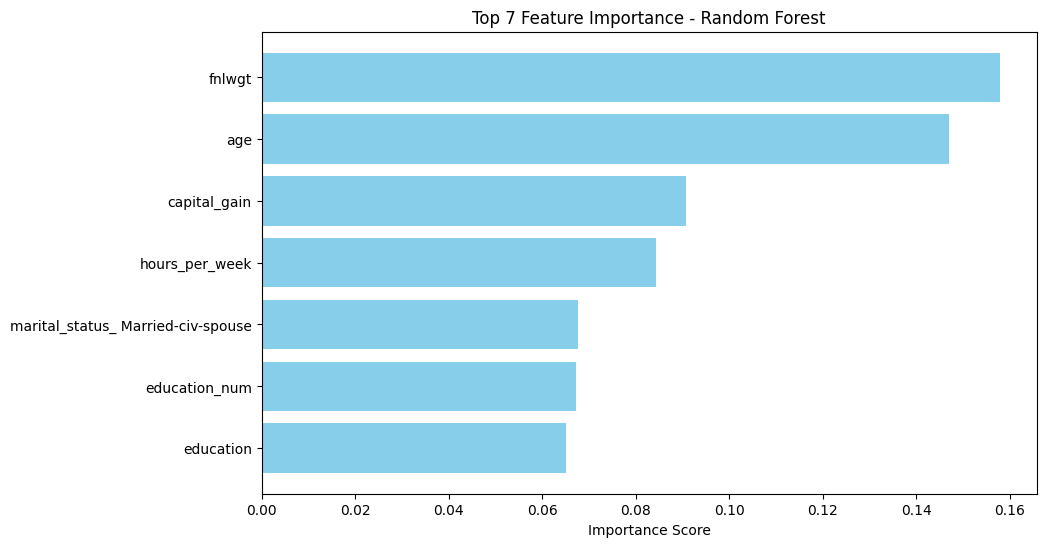

In [14]:
# Top 7 features importance
ohe_feature_names = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_cols).tolist()
all_feature_names = ordinal_cols + ohe_feature_names + numeric_cols

best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_proc, y_train)

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

top_7_features = feature_importance_df.sort_values(by='importance', ascending=False).head(7)


plt.figure(figsize=(10, 6))
plt.barh(top_7_features['feature'], top_7_features['importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 7 Feature Importance - Random Forest')
plt.gca().invert_yaxis()  
plt.show()
